# Trade Flow Network Analysis — Critical Minerals

This notebook analyses bilateral trade flows for critical minerals using BGS data.
We model each country's reported exports and imports as directed edges through a
**Global Market** hub node, compute network-level metrics, and visualise trade balances
and export concentration across commodities.

## 1. Setup

In [1]:

from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

DATA_DIR = Path("../data/bgs_data")

## 2. Load and Clean Trade Data

We read the BGS critical-minerals trade CSV, coerce `year` and `quantity` to numeric
types, and drop rows where either value is missing.  A brief summary is printed so we
can confirm the data loaded correctly.

In [2]:
trade_file = DATA_DIR / "bgs_critical_minerals_trade.csv"

df = pd.read_csv(trade_file, low_memory=False)

# Coerce numeric columns
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")

# Drop rows with missing year, quantity, country, or statistic_type
df = df.dropna(subset=["year", "quantity", "country", "statistic_type"])
df["year"] = df["year"].astype(int)

print(f"Records loaded      : {len(df):,}")
print(f"Commodities         : {df['commodity'].nunique()}")
print(f"Countries           : {df['country'].nunique()}")
print(f"Year range          : {df['year'].min()} – {df['year'].max()}")
print(f"Statistic types     : {sorted(df['statistic_type'].unique())}")
print()
print("Records per statistic type:")
print(df["statistic_type"].value_counts().to_string())

Records loaded      : 16,303
Commodities         : 5
Countries           : 132
Year range          : 1970 – 2023
Statistic types     : ['Exports', 'Imports']

Records per statistic type:
statistic_type
Imports    10258
Exports     6045


## 3. Build Trade Network

Because the BGS dataset records each country's own exports/imports rather than
bilateral pairs, we model trade flows through a synthetic **Global Market** hub:

* **Export edge**: `country → Global Market`  (weight = quantity)
* **Import edge**: `Global Market → country`  (weight = quantity)

This preserves directionality and allows standard network metrics to be computed.

In [3]:
def build_trade_network(
    trade_df: pd.DataFrame,
    commodity: str,
    year: int | None = None,
) -> nx.DiGraph:
    """Build a directed trade-flow graph for *commodity* (optionally filtered to *year*).

    Nodes  : individual countries + a synthetic 'Global Market' hub.
    Edges  : country → Global Market for exports; Global Market → country for imports.
    Weight : quantity traded (aggregated when multiple rows match).
    """
    subset = trade_df[trade_df["commodity"].str.lower() == commodity.lower()].copy()
    if year is not None:
        subset = subset[subset["year"] == year]

    G = nx.DiGraph()
    HUB = "Global Market"
    G.add_node(HUB, node_type="hub")

    exports = (
        subset[subset["statistic_type"] == "Exports"]
        .groupby("country")["quantity"]
        .sum()
    )
    imports = (
        subset[subset["statistic_type"] == "Imports"]
        .groupby("country")["quantity"]
        .sum()
    )

    for country, qty in exports.items():
        G.add_node(country, node_type="country")
        if G.has_edge(country, HUB):
            G[country][HUB]["weight"] += qty
        else:
            G.add_edge(country, HUB, weight=qty, flow_type="export")

    for country, qty in imports.items():
        G.add_node(country, node_type="country")
        if G.has_edge(HUB, country):
            G[HUB][country]["weight"] += qty
        else:
            G.add_edge(HUB, country, weight=qty, flow_type="import")

    return G


# Show which commodities have the most trade records
records_per_commodity = (
    df.groupby("commodity").size().sort_values(ascending=False)
)
print("Top 15 commodities by trade record count:")
print(records_per_commodity.head(15).to_string())

Top 15 commodities by trade record count:
commodity
iron ore          4015
barytes           3636
phosphate rock    3275
graphite          2770
fluorspar         2607


## 4. Network Metrics for the Top Commodity

For the commodity with the most trade records we:

1. Build an all-year network.
2. Compute **degree centrality** and **betweenness centrality** for each node.
3. Calculate each country's **trade balance** (total exports − total imports).
4. List the top exporters and importers.

In [4]:
top_commodity = records_per_commodity.index[0]
print(f"Top commodity: {top_commodity}  ({records_per_commodity.iloc[0]:,} records)\n")

G_top = build_trade_network(df, top_commodity)
print(f"Graph — nodes: {G_top.number_of_nodes()}, edges: {G_top.number_of_edges()}")

# --- Centrality ---
deg_cent = nx.degree_centrality(G_top)
bet_cent = nx.betweenness_centrality(G_top, weight="weight", normalized=True)

cent_df = pd.DataFrame(
    {
        "degree_centrality": deg_cent,
        "betweenness_centrality": bet_cent,
    }
).drop(index="Global Market", errors="ignore")

print("\nTop 10 countries by degree centrality:")
print(cent_df.sort_values("degree_centrality", ascending=False).head(10).to_string())

# --- Trade balance ---
commodity_df = df[df["commodity"].str.lower() == top_commodity.lower()]

exports_agg = (
    commodity_df[commodity_df["statistic_type"] == "Exports"]
    .groupby("country")["quantity"]
    .sum()
    .rename("total_exports")
)
imports_agg = (
    commodity_df[commodity_df["statistic_type"] == "Imports"]
    .groupby("country")["quantity"]
    .sum()
    .rename("total_imports")
)

balance_df = pd.concat([exports_agg, imports_agg], axis=1).fillna(0)
balance_df["trade_balance"] = balance_df["total_exports"] - balance_df["total_imports"]
balance_df = balance_df.sort_values("trade_balance", ascending=False)

print(f"\nTop 10 net exporters of {top_commodity}:")
print(balance_df.head(10)[["total_exports", "total_imports", "trade_balance"]].to_string())

print(f"\nTop 10 net importers of {top_commodity}:")
print(balance_df.tail(10)[["total_exports", "total_imports", "trade_balance"]].iloc[::-1].to_string())

Top commodity: iron ore  (4,015 records)

Graph — nodes: 90, edges: 140

Top 10 countries by degree centrality:
                 degree_centrality  betweenness_centrality
Albania                   0.022472                     0.0
Singapore                 0.022472                     0.0
Korea (Rep. of)           0.022472                     0.0
Malaysia                  0.022472                     0.0
Mexico                    0.022472                     0.0
Morocco                   0.022472                     0.0
Netherlands               0.022472                     0.0
Norway                    0.022472                     0.0
Philippines               0.022472                     0.0
Portugal                  0.022472                     0.0

Top 10 net exporters of iron ore:
              total_exports  total_imports  trade_balance
country                                                  
Brazil         3.191860e+09        45103.0   3.191815e+09
Australia      3.222856e+09   

## 5. Trade Balance Visualisation

A horizontal bar chart showing the net trade balance (exports − imports) for the
**10 biggest net exporters** and **10 biggest net importers** of the top commodity.
Bars are coloured on a diverging Red–Blue scale (blue = net exporter, red = net importer)
with the midpoint anchored at zero.

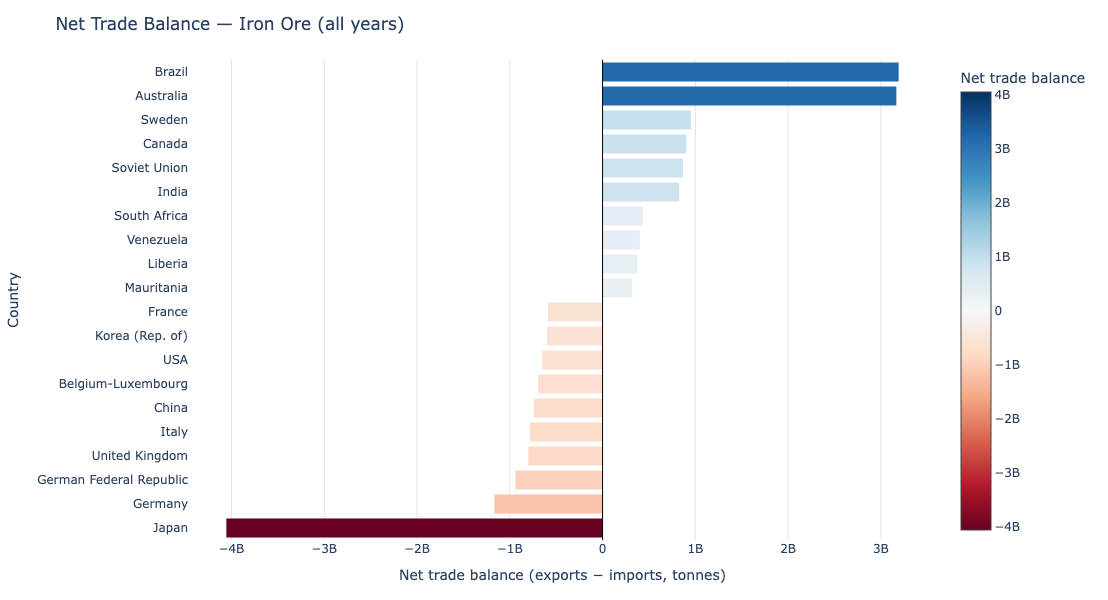

In [5]:
# Select top 10 exporters and top 10 importers
top_exporters = balance_df.head(10)
top_importers = balance_df.tail(10).iloc[::-1]  # most negative first
plot_df = pd.concat([top_exporters, top_importers]).drop_duplicates()
plot_df = plot_df.sort_values("trade_balance")

# Build a symmetrical colour scale anchored at 0
max_abs = plot_df["trade_balance"].abs().max()

fig = go.Figure(
    go.Bar(
        x=plot_df["trade_balance"],
        y=plot_df.index,
        orientation="h",
        marker=dict(
            color=plot_df["trade_balance"],
            colorscale="RdBu",
            cmin=-max_abs,
            cmax=max_abs,
            colorbar=dict(title="Net trade balance"),
            line=dict(width=0),
        ),
        hovertemplate="%{y}<br>Balance: %{x:,.0f}<extra></extra>",
    )
)

fig.add_vline(x=0, line_width=1, line_color="black")

fig.update_layout(
    title=f"Net Trade Balance — {top_commodity.title()} (all years)",
    xaxis_title="Net trade balance (exports − imports, tonnes)",
    yaxis_title="Country",
    height=600,
    margin=dict(l=160, r=40, t=60, b=60),
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(gridcolor="#e5e5e5"),
)

fig.show()

## 6. Multi-Commodity Comparison

For each of the **top 6 commodities** by trade record count we build a network and
extract:

| Metric | Description |
|---|---|
| `num_exporters` | Countries with reported exports |
| `num_importers` | Countries with reported imports |
| `total_exports` | Sum of all export quantities |
| `total_imports` | Sum of all import quantities |
| `top_exporter_share_pct` | % of total exports held by the single largest exporter |

A bar chart of **export concentration** (top-exporter share %) reveals which
critical minerals are dominated by a single country.

In [6]:
TOP_N = 6
top_commodities = records_per_commodity.head(TOP_N).index.tolist()

summary_rows = []

for commodity in top_commodities:
    G = build_trade_network(df, commodity)
    HUB = "Global Market"

    # Exporters: nodes with an edge into the hub
    exporters = [n for n in G.predecessors(HUB) if n != HUB]
    importers = [n for n in G.successors(HUB) if n != HUB]

    total_exports = sum(G[c][HUB]["weight"] for c in exporters)
    total_imports = sum(G[HUB][c]["weight"] for c in importers)

    if exporters and total_exports > 0:
        max_export = max(G[c][HUB]["weight"] for c in exporters)
        top_share = 100 * max_export / total_exports
        top_exporter = max(exporters, key=lambda c: G[c][HUB]["weight"])
    else:
        top_share = 0.0
        top_exporter = "N/A"

    summary_rows.append(
        {
            "commodity": commodity,
            "num_exporters": len(exporters),
            "num_importers": len(importers),
            "total_exports": total_exports,
            "total_imports": total_imports,
            "top_exporter": top_exporter,
            "top_exporter_share_pct": round(top_share, 1),
        }
    )

summary_df = pd.DataFrame(summary_rows).set_index("commodity")
print("Multi-commodity network summary:")
print(summary_df.to_string())

Multi-commodity network summary:
                num_exporters  num_importers  total_exports  total_imports top_exporter  top_exporter_share_pct
commodity                                                                                                      
iron ore                   67             73   1.327633e+10   1.554833e+10    Australia                    24.3
barytes                    58             80   1.016337e+08   1.034255e+08        China                    33.9
phosphate rock             52             84   1.269443e+09   1.361389e+09      Morocco                    33.8
graphite                   41             73   1.005233e+07   1.206704e+07        China                    35.7
fluorspar                  42             72   7.530665e+07   8.976418e+07        China                    32.2


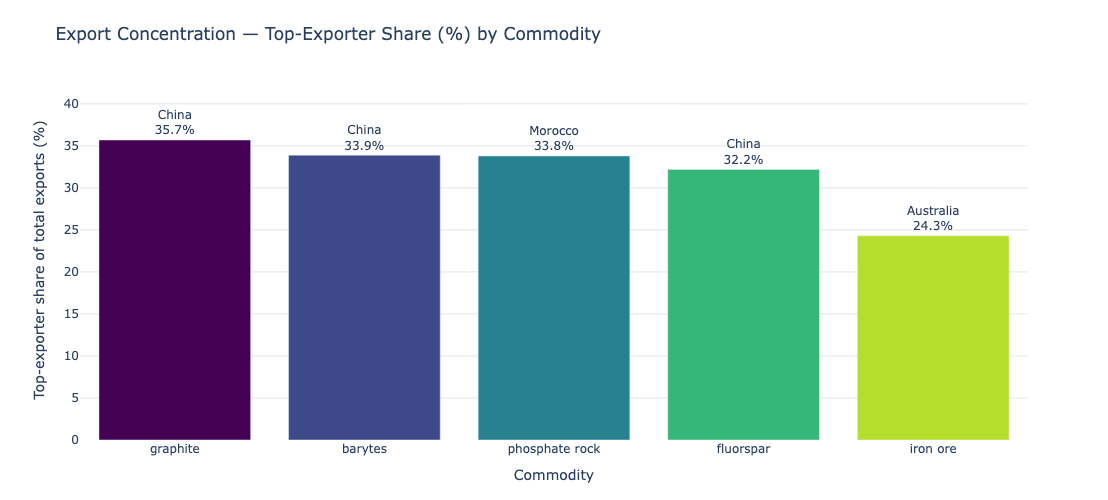

In [7]:
plot_s = summary_df.sort_values("top_exporter_share_pct", ascending=False)

fig2 = go.Figure(
    go.Bar(
        x=plot_s.index,
        y=plot_s["top_exporter_share_pct"],
        text=[
            f"{row['top_exporter']}<br>{row['top_exporter_share_pct']:.1f}%"
            for _, row in plot_s.iterrows()
        ],
        textposition="outside",
        marker_color=px.colors.sequential.Viridis[
            :: max(1, len(px.colors.sequential.Viridis) // len(plot_s))
        ][: len(plot_s)],
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Top exporter share: %{y:.1f}%<br>"
            "<extra></extra>"
        ),
    )
)

fig2.add_hline(
    y=50,
    line_dash="dash",
    line_color="red",
    annotation_text="50% threshold",
    annotation_position="top right",
)

fig2.update_layout(
    title="Export Concentration — Top-Exporter Share (%) by Commodity",
    xaxis_title="Commodity",
    yaxis_title="Top-exporter share of total exports (%)",
    yaxis_range=[0, min(110, plot_s["top_exporter_share_pct"].max() * 1.2)],
    height=500,
    margin=dict(t=80, b=60),
    plot_bgcolor="white",
    paper_bgcolor="white",
    yaxis=dict(gridcolor="#e5e5e5"),
)

fig2.show()

## Summary

* The **Global Market hub model** lets us apply standard directed-graph metrics to
  single-sided trade statistics, giving a practical proxy for supply-chain centrality.
* **Trade balance** analysis (Section 4–5) highlights which countries are chronic net
  exporters versus net importers for each mineral.
* **Export concentration** (Section 6) flags commodities where supply is dominated by
  a single country — a key indicator of geopolitical supply-chain risk.